<a href="https://colab.research.google.com/github/pxu/Generative_Deep_Learning_2nd_Edition/blob/main/notebooks/07_ebm/01_ebm/ebm_assignment6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚡️ Energy-Based Models

In this notebook, we'll walk through the steps required to train your own Energy Based Model to predict the distribution of a demo dataset

The code is adapted from the excellent ['Deep Energy-Based Generative Models' tutorial](https://uvadlc-notebooks.readthedocs.io/en/latest/tutorial_notebooks/tutorial8/Deep_Energy_Models.html) created by Phillip Lippe.

In [20]:
import numpy as np

import tensorflow as tf
from tensorflow.keras import (
    datasets,
    layers,
    models,
    optimizers,
    activations,
    metrics,
    callbacks,
)

import random

In [21]:
import matplotlib.pyplot as plt


def sample_batch(dataset):
    batch = dataset.take(1).get_single_element()
    if isinstance(batch, tuple):
        batch = batch[0]
    return batch.numpy()


def display(
    images, n=10, size=(20, 3), cmap="gray_r", as_type="float32", save_to=None
):
    """
    Displays n random images from each one of the supplied arrays.
    """
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    for i in range(n):
        _ = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")

    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")

    plt.show()

## 0. Parameters <a name="parameters"></a>

In [22]:
IMAGE_SIZE = 32
CHANNELS = 1
STEP_SIZE = 10


# Reason:
# The number of Langevin sampling steps is the main computational bottleneck
# in energy-based models, because each step requires a forward + backward pass
# through the network.
# Reducing STEPS from 60 to 20 cuts the sampling cost by ~3x, which
# significantly shortens each training epoch.
# CD-20 (Contrastive Divergence with ~20 steps) is commonly used in practice
# and still provides stable training and good sample quality.
# This keeps image quality high while reducing total training time.
STEPS = 20   # Reduced from 60.


NOISE = 0.005
ALPHA = 0.1
GRADIENT_CLIP = 0.03
BATCH_SIZE = 128
BUFFER_SIZE = 8192
LEARNING_RATE = 0.0001
EPOCHS = 120 #60
LOAD_MODEL = False

In [23]:
# Load the data
(x_train, _), (x_test, _) = datasets.mnist.load_data()

In [24]:
# Preprocess the data


def preprocess(imgs):
    """
    Normalize and reshape the images
    """
    imgs = (imgs.astype("float32") - 127.5) / 127.5
    imgs = np.pad(imgs, ((0, 0), (2, 2), (2, 2)), constant_values=-1.0)
    imgs = np.expand_dims(imgs, -1)
    return imgs


x_train = preprocess(x_train)
x_test = preprocess(x_test)

In [25]:
x_train = tf.data.Dataset.from_tensor_slices(x_train).batch(BATCH_SIZE)
x_test = tf.data.Dataset.from_tensor_slices(x_test).batch(BATCH_SIZE)

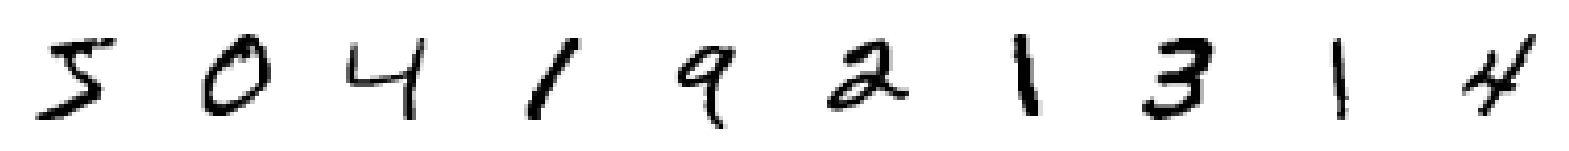

In [26]:
# Show some items of clothing from the training set
train_sample = sample_batch(x_train)
display(train_sample)

## 2. Build the EBM network <a name="train"></a>

In [27]:
ebm_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
x = layers.Conv2D(
    16, kernel_size=5, strides=2, padding="same", activation=activations.swish
)(ebm_input)
x = layers.Conv2D(
    32, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Conv2D(
    64, kernel_size=3, strides=2, padding="same", activation=activations.swish
)(x)
x = layers.Flatten()(x)
x = layers.Dense(64, activation=activations.swish)(x)
ebm_output = layers.Dense(1)(x)
model = models.Model(ebm_input, ebm_output)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 32)       │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,993 (300.75 KB)

 Trainable params: 76,993 (300.75 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
if LOAD_MODEL:
    model.load_weights("./models/model.h5")

## 2. Set up a Langevin sampler function <a name="sampler"></a>

In [29]:
# Function to generate samples using Langevin Dynamics
def generate_samples(
    model, inp_imgs, steps, step_size, noise, return_img_per_step=False
):
    imgs_per_step = []
    for _ in range(steps):
        inp_imgs += tf.random.normal(inp_imgs.shape, mean=0, stddev=noise)
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        with tf.GradientTape() as tape:
            tape.watch(inp_imgs)
            out_score = model(inp_imgs)
        grads = tape.gradient(out_score, inp_imgs)
        grads = tf.clip_by_value(grads, -GRADIENT_CLIP, GRADIENT_CLIP)
        inp_imgs += step_size * grads
        inp_imgs = tf.clip_by_value(inp_imgs, -1.0, 1.0)
        if return_img_per_step:
            imgs_per_step.append(inp_imgs)
    if return_img_per_step:
        return tf.stack(imgs_per_step, axis=0)
    else:
        return inp_imgs

## 3. Set up a buffer to store examples <a name="buffer"></a>

In [30]:
class Buffer:
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.examples = [
            tf.random.uniform(shape=(1, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2
            - 1
            for _ in range(BATCH_SIZE)
        ]

    def sample_new_exmps(self, steps, step_size, noise):
        n_new = np.random.binomial(BATCH_SIZE, 0.05)
        rand_imgs = (
            tf.random.uniform((n_new, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
        )
        old_imgs = tf.concat(
            random.choices(self.examples, k=BATCH_SIZE - n_new), axis=0
        )
        inp_imgs = tf.concat([rand_imgs, old_imgs], axis=0)
        inp_imgs = generate_samples(
            self.model, inp_imgs, steps=steps, step_size=step_size, noise=noise
        )
        self.examples = tf.split(inp_imgs, BATCH_SIZE, axis=0) + self.examples
        self.examples = self.examples[:BUFFER_SIZE]
        return inp_imgs

In [31]:
class EBM(models.Model):
    def __init__(self):
        super(EBM, self).__init__()
        self.model = model
        self.buffer = Buffer(self.model)
        self.alpha = ALPHA
        self.loss_metric = metrics.Mean(name="loss")
        self.reg_loss_metric = metrics.Mean(name="reg")
        self.cdiv_loss_metric = metrics.Mean(name="cdiv")
        self.real_out_metric = metrics.Mean(name="real")
        self.fake_out_metric = metrics.Mean(name="fake")

    @property
    def metrics(self):
        return [
            self.loss_metric,
            self.reg_loss_metric,
            self.cdiv_loss_metric,
            self.real_out_metric,
            self.fake_out_metric,
        ]

    def train_step(self, real_imgs):
        real_imgs += tf.random.normal(
            shape=tf.shape(real_imgs), mean=0, stddev=NOISE
        )
        real_imgs = tf.clip_by_value(real_imgs, -1.0, 1.0)
        fake_imgs = self.buffer.sample_new_exmps(
            steps=STEPS, step_size=STEP_SIZE, noise=NOISE
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        with tf.GradientTape() as training_tape:
            real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
            cdiv_loss = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
                real_out, axis=0
            )
            reg_loss = self.alpha * tf.reduce_mean(
                real_out**2 + fake_out**2, axis=0
            )
            loss = cdiv_loss + reg_loss
        grads = training_tape.gradient(loss, self.model.trainable_variables)
        self.optimizer.apply_gradients(
            zip(grads, self.model.trainable_variables)
        )
        self.loss_metric.update_state(loss)
        self.reg_loss_metric.update_state(reg_loss)
        self.cdiv_loss_metric.update_state(cdiv_loss)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, real_imgs):
        batch_size = real_imgs.shape[0]
        fake_imgs = (
            tf.random.uniform((batch_size, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
            * 2
            - 1
        )
        inp_imgs = tf.concat([real_imgs, fake_imgs], axis=0)
        real_out, fake_out = tf.split(self.model(inp_imgs), 2, axis=0)
        cdiv = tf.reduce_mean(fake_out, axis=0) - tf.reduce_mean(
            real_out, axis=0
        )
        self.cdiv_loss_metric.update_state(cdiv)
        self.real_out_metric.update_state(tf.reduce_mean(real_out, axis=0))
        self.fake_out_metric.update_state(tf.reduce_mean(fake_out, axis=0))
        return {m.name: m.result() for m in self.metrics[2:]}

In [32]:
ebm = EBM()

## 3. Train the EBM network <a name="train"></a>

In [33]:
# Compile and train the model
ebm.compile(
    optimizer=optimizers.Adam(learning_rate=LEARNING_RATE), run_eagerly=True
)

In [34]:
tensorboard_callback = callbacks.TensorBoard(log_dir="./logs")


# This callback generates sample images at the end of each epoch.
# We reduce the Langevin sampling steps from 1000 to 200 to significantly
# speed up training while still preserving good visual sample quality.
# This change does NOT affect model training, only visualization speed.

class ImageGenerator(callbacks.Callback):
    def __init__(self, num_img):
        super().__init__()
        self.num_img = num_img

    def on_epoch_end(self, epoch, logs=None):
        # -----------------------------------------
        # 1. Generate initial random noise images
        # -----------------------------------------
        start_imgs = (
            np.random.uniform(
                size=(self.num_img, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
            ) * 2 - 1
        )

        # ------------------------------------------------------------
        # 2. Generate images using Langevin Dynamics
        # NOTE: steps reduced to 200 (from original 1000):
        # - This speeds up training significantly.
        # - 200 steps still produce clear samples.
        # - This only affects visualization, not training quality.
        # ------------------------------------------------------------
        generated_images = generate_samples(
            ebm.model,
            start_imgs,
            steps=200,              # Reduced from 1000 for faster training
            step_size=STEP_SIZE,
            noise=NOISE,
            return_img_per_step=False,
        ).numpy()

        # Save generated samples for visualization
        display(
            generated_images,
            save_to="./output/generated_img_%03d.png" % epoch,
        )

        # ------------------------------------------------------------
        # 3. Display negative samples stored in the replay buffer
        # ------------------------------------------------------------
        example_images = tf.concat(
            random.choices(ebm.buffer.examples, k=10), axis=0
        ).numpy()

        display(
            example_images,
            save_to="./output/example_img_%03d.png" % epoch,
        )


# Create the callback instance
image_generator_callback = ImageGenerator(num_img=10)

In [35]:
import os
if not os.path.exists("models"):
    os.makedirs("models")

if not os.path.exists("output"):
    os.makedirs("output")

Epoch 1/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - cdiv: -0.2837 - fake: 0.4063 - loss: -0.1760 - real: 0.6900 - reg: 0.1077
Saved to ./output/generated_img_000.png


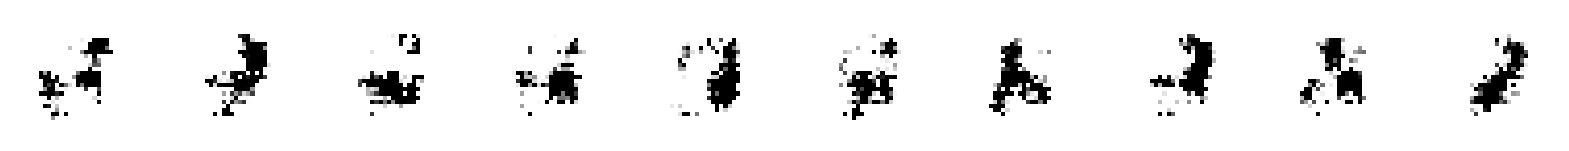


Saved to ./output/example_img_000.png


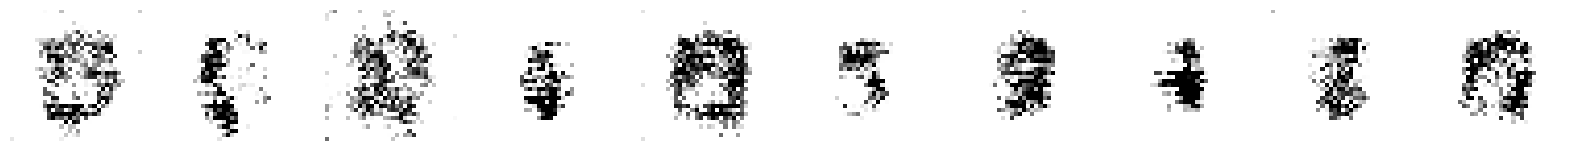

469/469 ━━━━━━━━━━━━━━━━━━━━ 297s 632ms/step - cdiv: -0.3069 - fake: 0.3677 - loss: -0.2017 - real: 0.6746 - reg: 0.1052 - val_cdiv: -3.4759 - val_fake: -2.9012 - val_real: 0.5747
Epoch 2/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - cdiv: -0.2145 - fake: -0.0437 - loss: -0.1323 - real: 0.1708 - reg: 0.0822
Saved to ./output/generated_img_001.png


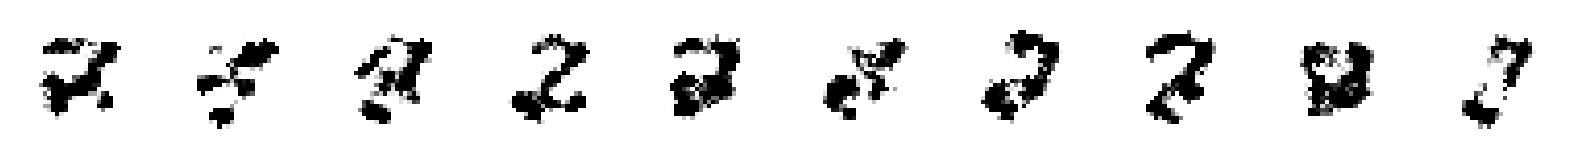


Saved to ./output/example_img_001.png


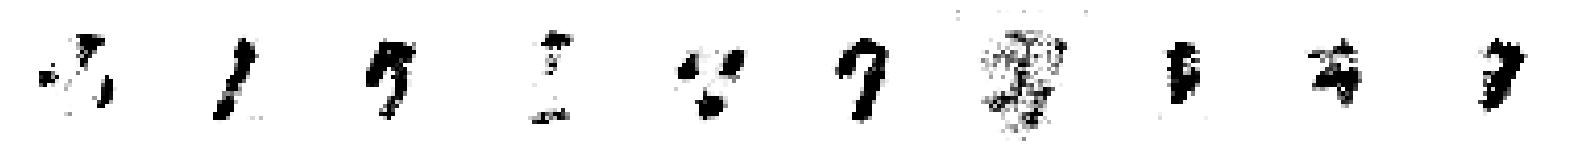

469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 627ms/step - cdiv: -0.1340 - fake: -0.0390 - loss: -0.0779 - real: 0.0950 - reg: 0.0561 - val_cdiv: -5.0928 - val_fake: -5.1070 - val_real: -0.0142
Epoch 3/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 618ms/step - cdiv: -0.0545 - fake: -0.0159 - loss: -0.0320 - real: 0.0386 - reg: 0.0225
Saved to ./output/generated_img_002.png


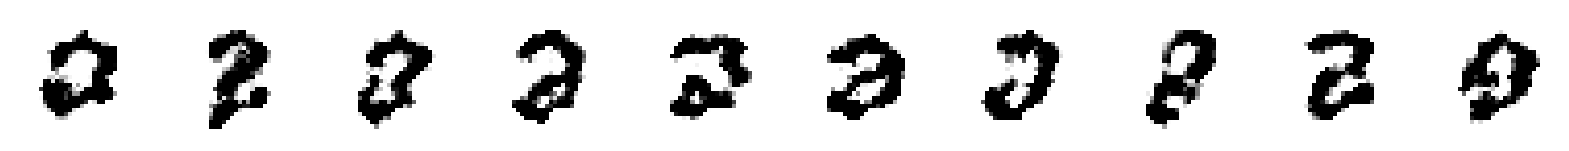


Saved to ./output/example_img_002.png


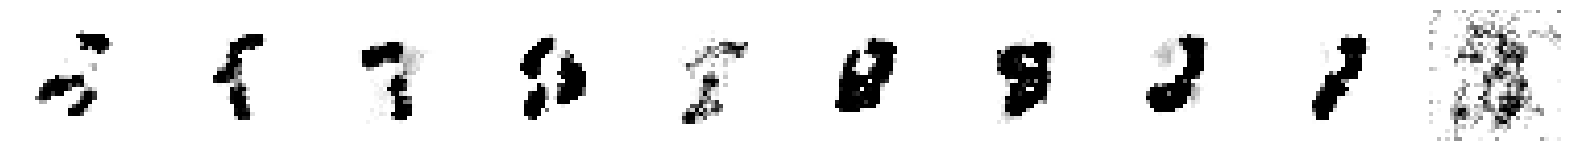

469/469 ━━━━━━━━━━━━━━━━━━━━ 297s 634ms/step - cdiv: -0.0397 - fake: -0.0127 - loss: -0.0232 - real: 0.0269 - reg: 0.0165 - val_cdiv: -7.1020 - val_fake: -7.1596 - val_real: -0.0576
Epoch 4/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - cdiv: -0.0221 - fake: -0.0094 - loss: -0.0114 - real: 0.0127 - reg: 0.0107
Saved to ./output/generated_img_003.png


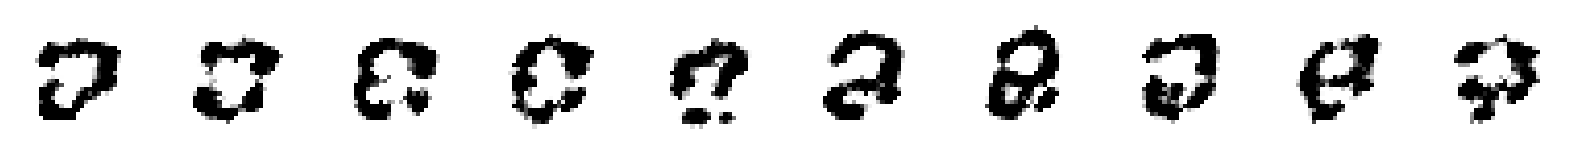


Saved to ./output/example_img_003.png


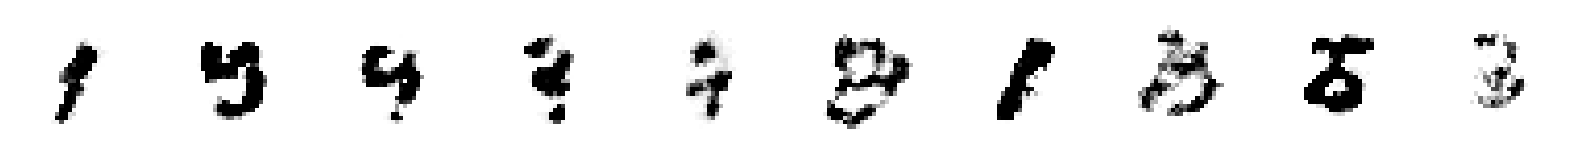

469/469 ━━━━━━━━━━━━━━━━━━━━ 297s 632ms/step - cdiv: -0.0160 - fake: -0.0047 - loss: -0.0080 - real: 0.0113 - reg: 0.0080 - val_cdiv: -8.8229 - val_fake: -8.8674 - val_real: -0.0445
Epoch 5/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 619ms/step - cdiv: -0.0080 - fake: -0.0077 - loss: -0.0022 - real: 2.4757e-04 - reg: 0.0057
Saved to ./output/generated_img_004.png


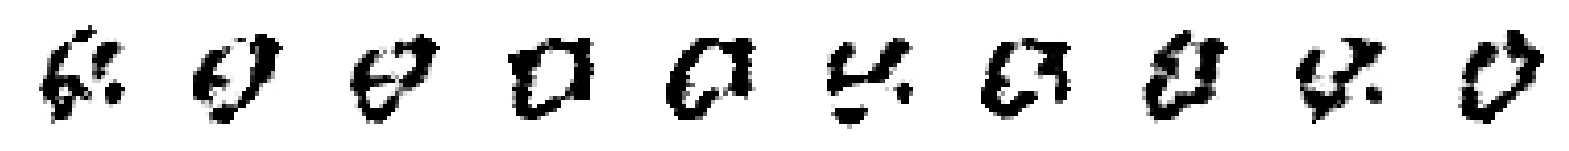


Saved to ./output/example_img_004.png


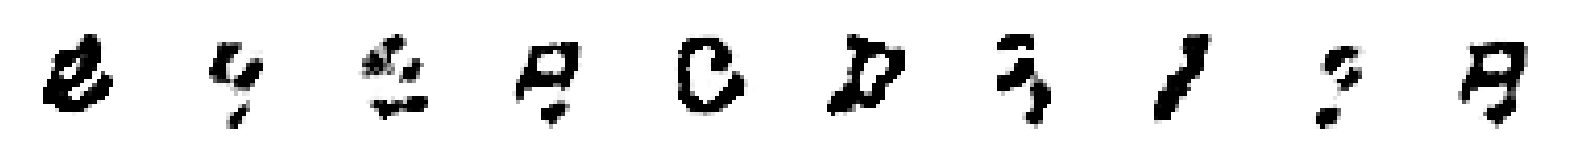

469/469 ━━━━━━━━━━━━━━━━━━━━ 298s 635ms/step - cdiv: -0.0031 - fake: -0.0010 - loss: 6.5177e-04 - real: 0.0021 - reg: 0.0038 - val_cdiv: -9.6794 - val_fake: -9.6919 - val_real: -0.0126
Epoch 6/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 626ms/step - cdiv: 0.0058 - fake: -4.8963e-04 - loss: 0.0072 - real: -0.0063 - reg: 0.0014
Saved to ./output/generated_img_005.png


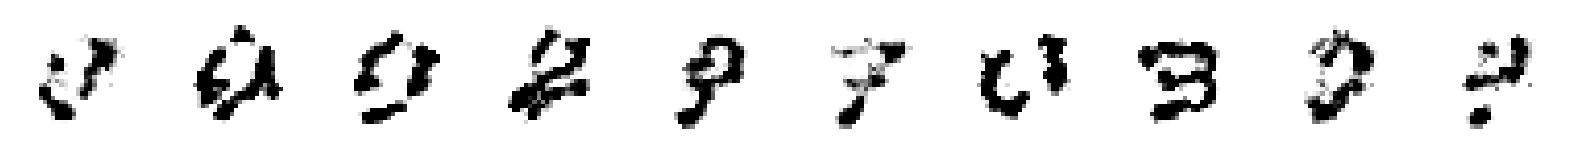


Saved to ./output/example_img_005.png


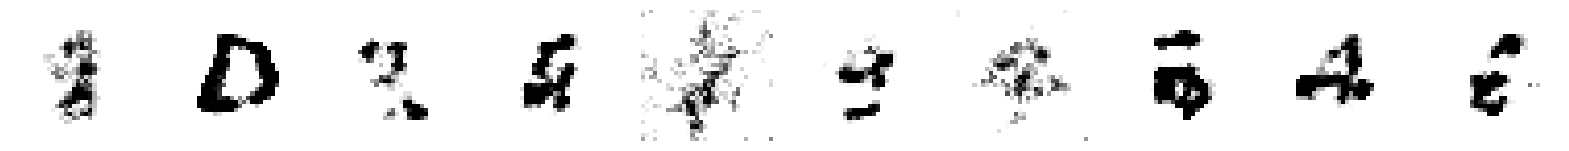

469/469 ━━━━━━━━━━━━━━━━━━━━ 301s 641ms/step - cdiv: 0.0032 - fake: 0.0010 - loss: 0.0044 - real: -0.0022 - reg: 0.0012 - val_cdiv: -9.5597 - val_fake: -9.5703 - val_real: -0.0106
Epoch 7/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - cdiv: -0.0056 - fake: -0.0050 - loss: -0.0026 - real: 6.6783e-04 - reg: 0.0030
Saved to ./output/generated_img_006.png


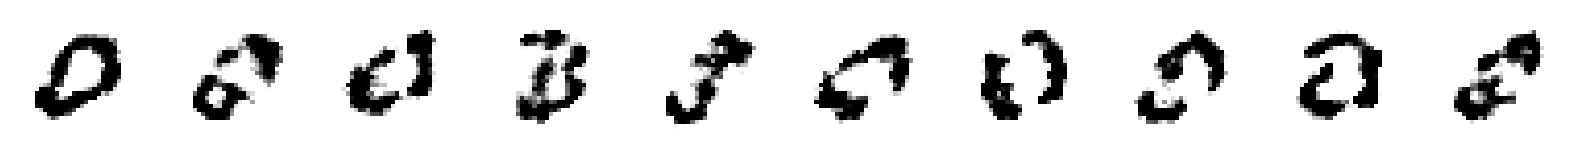


Saved to ./output/example_img_006.png


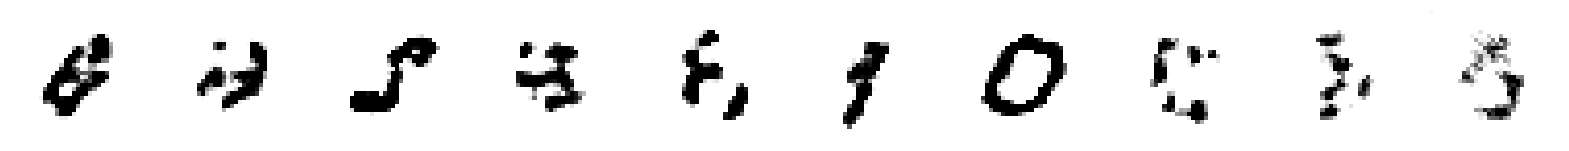

469/469 ━━━━━━━━━━━━━━━━━━━━ 300s 639ms/step - cdiv: -0.0081 - fake: -0.0016 - loss: -0.0046 - real: 0.0065 - reg: 0.0035 - val_cdiv: -12.1172 - val_fake: -12.1363 - val_real: -0.0191
Epoch 8/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - cdiv: -0.0143 - fake: -0.0135 - loss: -0.0068 - real: 7.3043e-04 - reg: 0.0075
Saved to ./output/generated_img_007.png


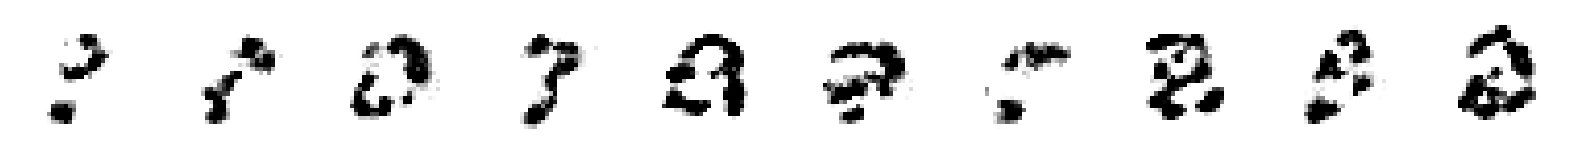


Saved to ./output/example_img_007.png


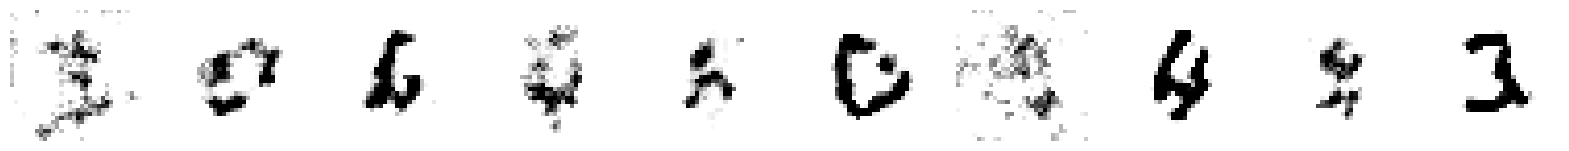

469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 628ms/step - cdiv: -0.0067 - fake: -0.0029 - loss: -0.0017 - real: 0.0038 - reg: 0.0049 - val_cdiv: -13.6235 - val_fake: -13.6272 - val_real: -0.0036
Epoch 9/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - cdiv: 0.0023 - fake: -0.0013 - loss: 0.0039 - real: -0.0036 - reg: 0.0016
Saved to ./output/generated_img_008.png


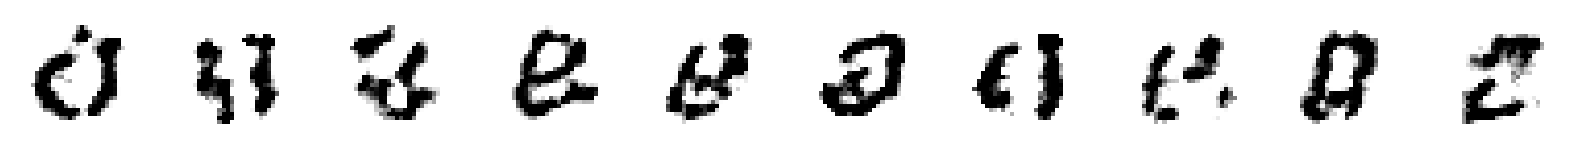


Saved to ./output/example_img_008.png


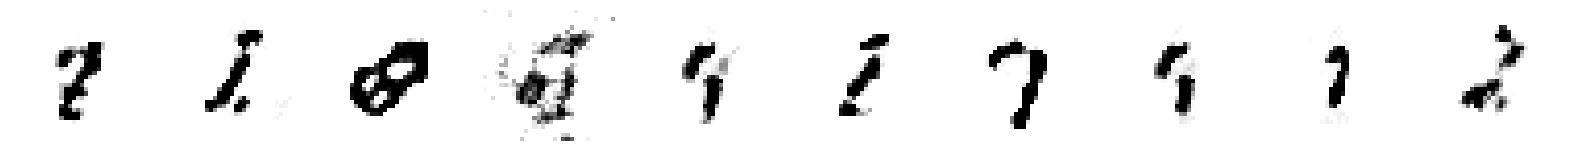

469/469 ━━━━━━━━━━━━━━━━━━━━ 297s 632ms/step - cdiv: 7.5355e-04 - fake: 8.8208e-04 - loss: 0.0023 - real: 1.2853e-04 - reg: 0.0016 - val_cdiv: -14.0262 - val_fake: -14.0444 - val_real: -0.0182
Epoch 10/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 616ms/step - cdiv: -0.0056 - fake: -0.0059 - loss: -0.0022 - real: -3.1477e-04 - reg: 0.0033
Saved to ./output/generated_img_009.png


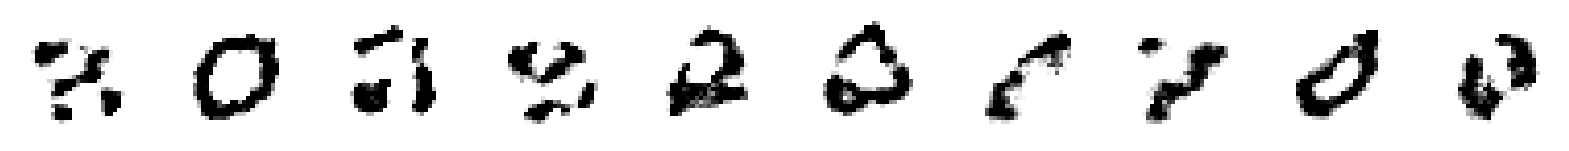


Saved to ./output/example_img_009.png


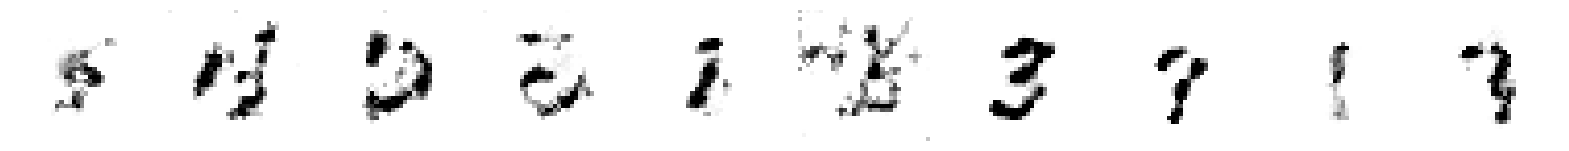

469/469 ━━━━━━━━━━━━━━━━━━━━ 296s 632ms/step - cdiv: -0.0067 - fake: -0.0025 - loss: -0.0034 - real: 0.0042 - reg: 0.0033 - val_cdiv: -16.5522 - val_fake: -16.5854 - val_real: -0.0332
Epoch 11/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - cdiv: -0.0155 - fake: -0.0097 - loss: -0.0079 - real: 0.0058 - reg: 0.0075
Saved to ./output/generated_img_010.png


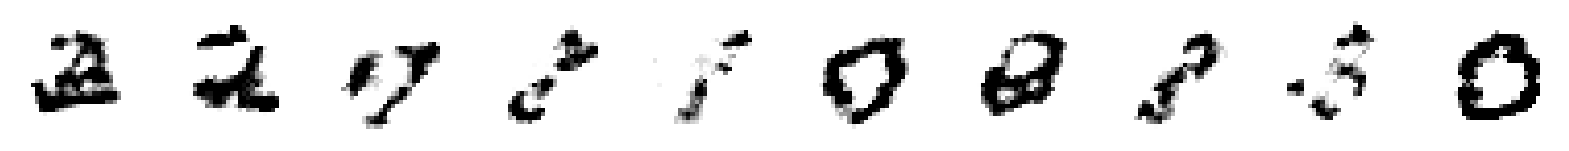


Saved to ./output/example_img_010.png


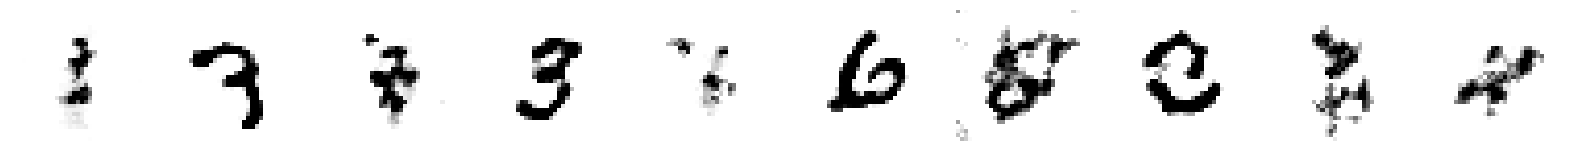

469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 628ms/step - cdiv: -0.0110 - fake: -0.0036 - loss: -0.0051 - real: 0.0075 - reg: 0.0059 - val_cdiv: -19.0610 - val_fake: -19.0428 - val_real: 0.0182
Epoch 12/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - cdiv: -0.0027 - fake: -0.0047 - loss: 6.4648e-04 - real: -0.0020 - reg: 0.0034
Saved to ./output/generated_img_011.png


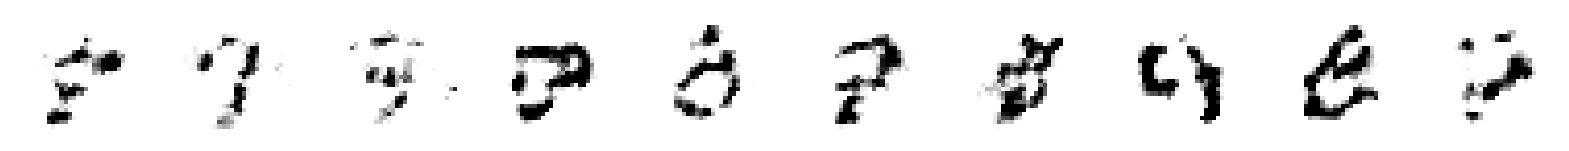


Saved to ./output/example_img_011.png


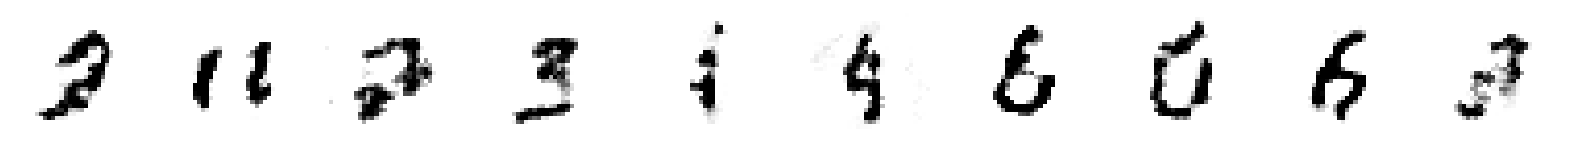

469/469 ━━━━━━━━━━━━━━━━━━━━ 291s 622ms/step - cdiv: -0.0017 - fake: -6.9612e-04 - loss: 7.6144e-04 - real: 9.7640e-04 - reg: 0.0024 - val_cdiv: -19.9007 - val_fake: -19.9167 - val_real: -0.0160
Epoch 13/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 604ms/step - cdiv: -0.0068 - fake: -0.0043 - loss: -0.0027 - real: 0.0025 - reg: 0.0042
Saved to ./output/generated_img_012.png


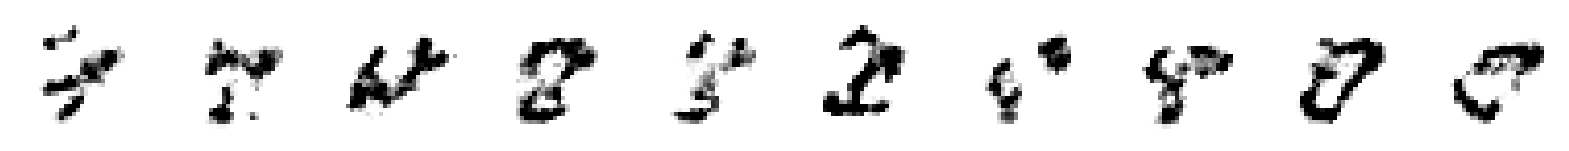


Saved to ./output/example_img_012.png


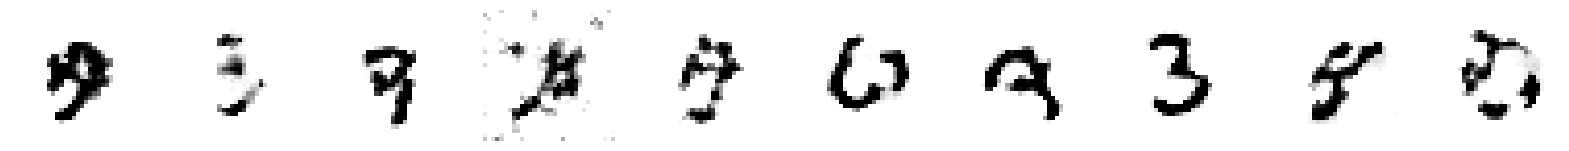

469/469 ━━━━━━━━━━━━━━━━━━━━ 290s 619ms/step - cdiv: -0.0033 - fake: -3.4431e-04 - loss: -5.2824e-04 - real: 0.0030 - reg: 0.0028 - val_cdiv: -21.1032 - val_fake: -21.1093 - val_real: -0.0061
Epoch 14/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 606ms/step - cdiv: -0.0140 - fake: -0.0092 - loss: -0.0063 - real: 0.0047 - reg: 0.0077
Saved to ./output/generated_img_013.png


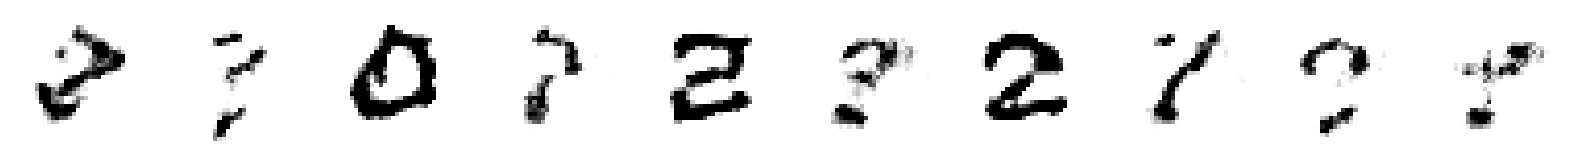


Saved to ./output/example_img_013.png


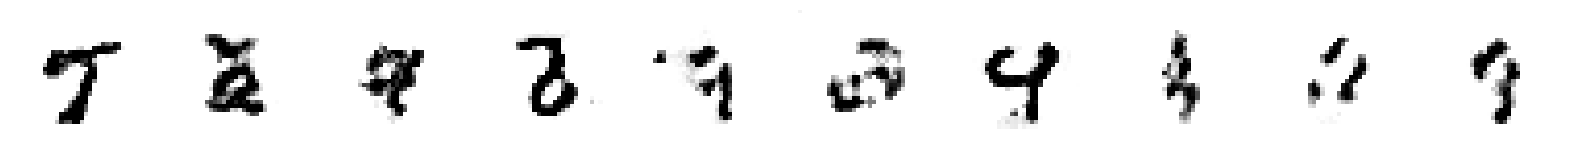

469/469 ━━━━━━━━━━━━━━━━━━━━ 291s 620ms/step - cdiv: -0.0088 - fake: -0.0033 - loss: -0.0033 - real: 0.0055 - reg: 0.0055 - val_cdiv: -22.9130 - val_fake: -22.8884 - val_real: 0.0246
Epoch 15/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - cdiv: -0.0085 - fake: -0.0053 - loss: -0.0030 - real: 0.0032 - reg: 0.0055
Saved to ./output/generated_img_014.png


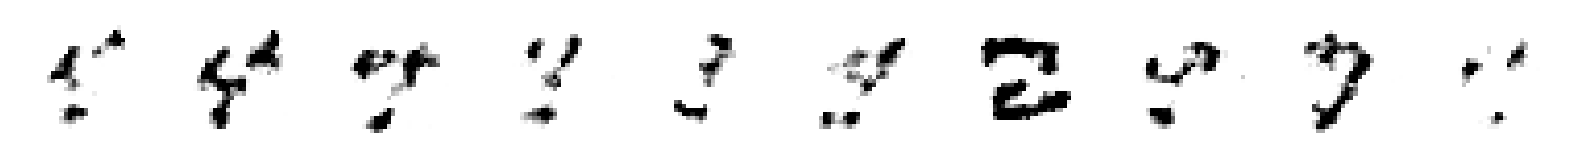


Saved to ./output/example_img_014.png


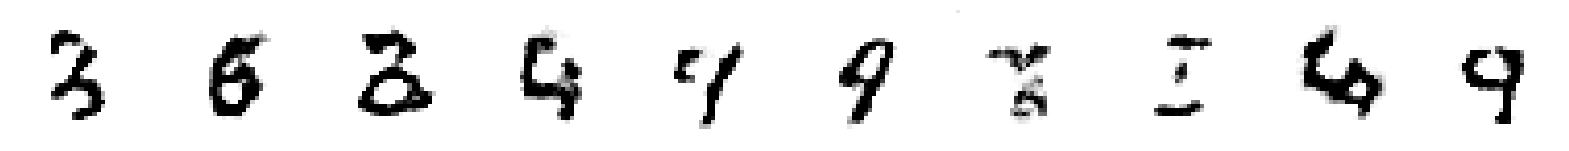

469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 626ms/step - cdiv: -0.0040 - fake: -0.0012 - loss: -8.2538e-04 - real: 0.0028 - reg: 0.0031 - val_cdiv: -23.9953 - val_fake: -23.9347 - val_real: 0.0606
Epoch 16/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - cdiv: -0.0037 - fake: -0.0022 - loss: -6.2843e-04 - real: 0.0015 - reg: 0.0031
Saved to ./output/generated_img_015.png


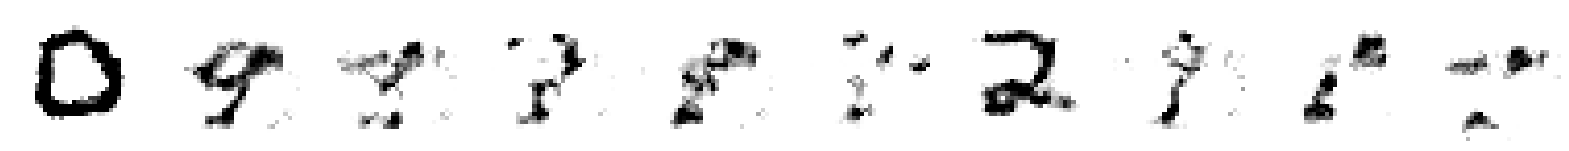


Saved to ./output/example_img_015.png


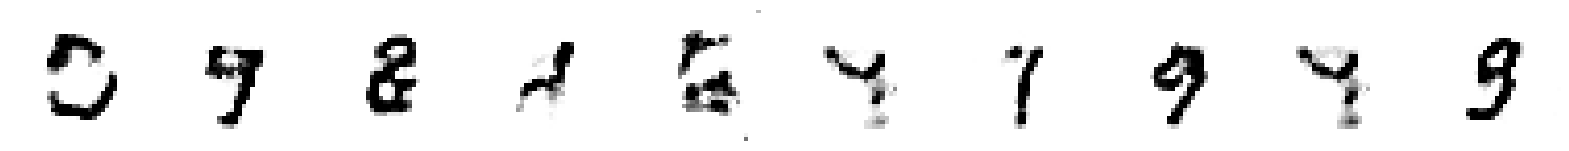

469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 629ms/step - cdiv: -0.0040 - fake: -0.0010 - loss: -0.0011 - real: 0.0030 - reg: 0.0030 - val_cdiv: -25.2711 - val_fake: -25.2575 - val_real: 0.0136
Epoch 17/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - cdiv: -0.3678 - fake: -0.1880 - loss: -0.1773 - real: 0.1798 - reg: 0.1905
Saved to ./output/generated_img_016.png


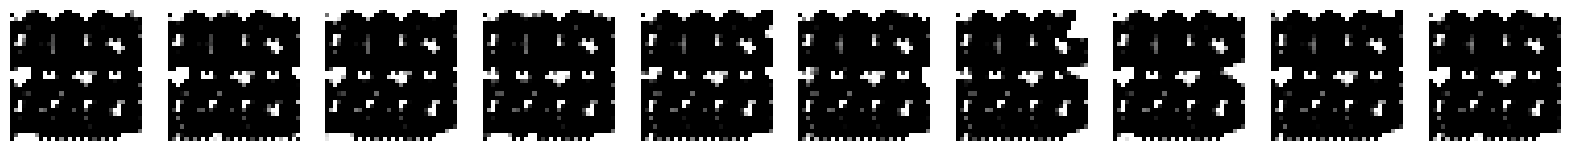


Saved to ./output/example_img_016.png


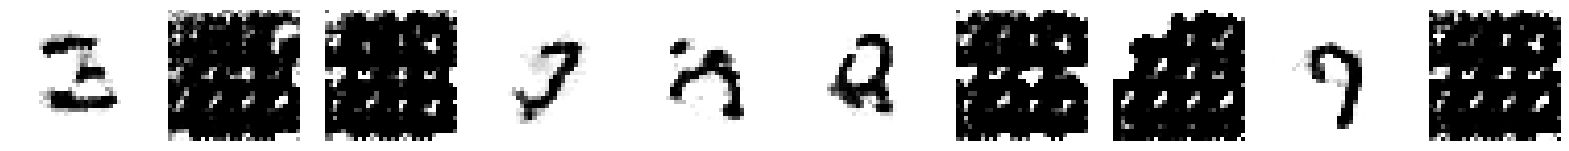

469/469 ━━━━━━━━━━━━━━━━━━━━ 296s 630ms/step - cdiv: -1.0816 - fake: -0.5488 - loss: -0.5342 - real: 0.5328 - reg: 0.5474 - val_cdiv: -19.4636 - val_fake: -17.9870 - val_real: 1.4766
Epoch 18/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - cdiv: -3.5952 - fake: -1.8057 - loss: -1.8012 - real: 1.7895 - reg: 1.7940
Saved to ./output/generated_img_017.png


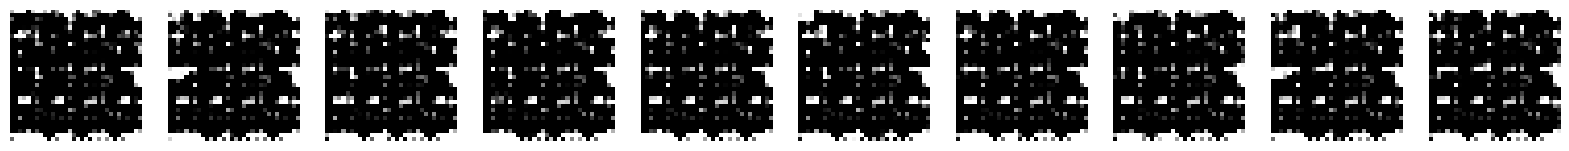


Saved to ./output/example_img_017.png


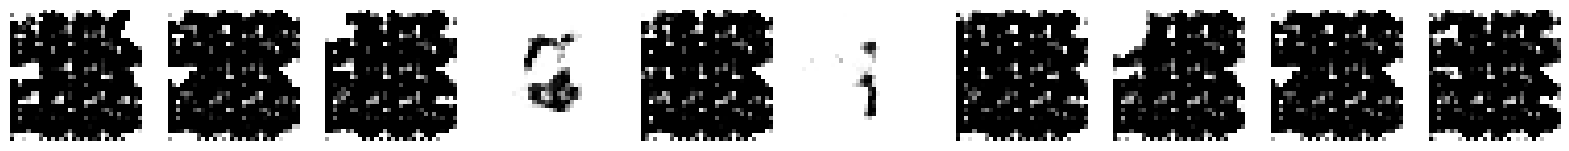

469/469 ━━━━━━━━━━━━━━━━━━━━ 294s 626ms/step - cdiv: -4.3681 - fake: -2.1956 - loss: -2.1836 - real: 2.1724 - reg: 2.1845 - val_cdiv: -18.8564 - val_fake: -16.3417 - val_real: 2.5147
Epoch 19/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 607ms/step - cdiv: -6.1136 - fake: -3.0690 - loss: -3.0687 - real: 3.0446 - reg: 3.0449
Saved to ./output/generated_img_018.png


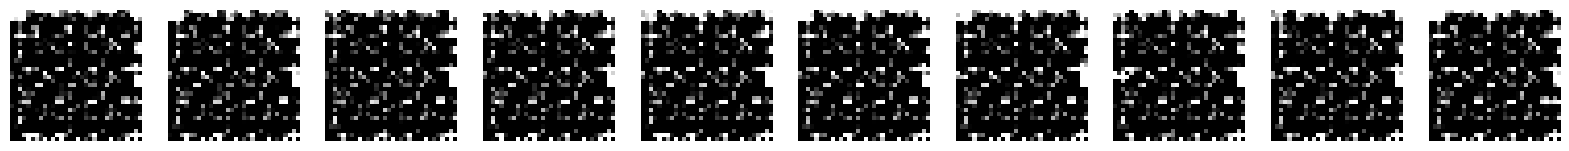


Saved to ./output/example_img_018.png


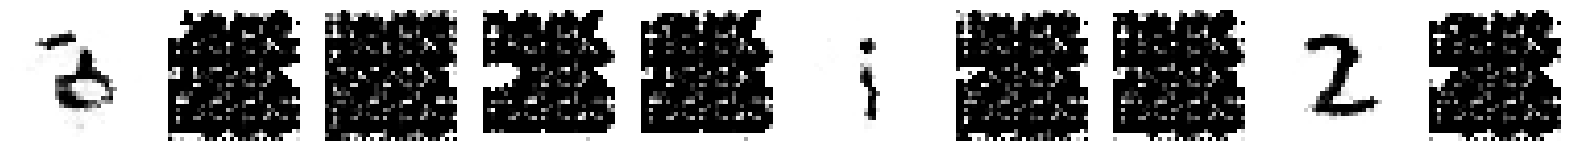

469/469 ━━━━━━━━━━━━━━━━━━━━ 293s 625ms/step - cdiv: -6.4707 - fake: -3.2459 - loss: -3.2373 - real: 3.2248 - reg: 3.2334 - val_cdiv: -18.3249 - val_fake: -14.7404 - val_real: 3.5846
Epoch 20/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - cdiv: -7.6876 - fake: -3.8420 - loss: -3.8536 - real: 3.8457 - reg: 3.8340
Saved to ./output/generated_img_019.png


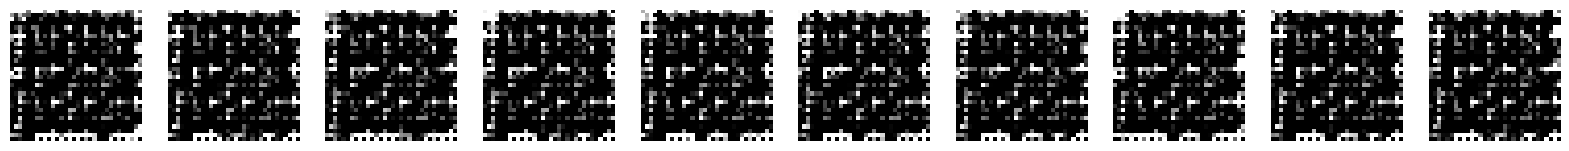


Saved to ./output/example_img_019.png


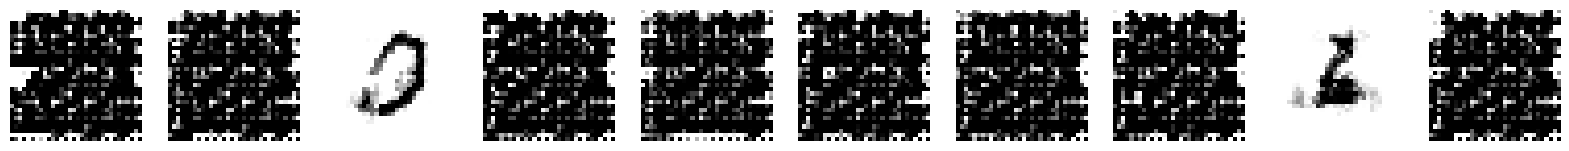

469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 629ms/step - cdiv: -8.0510 - fake: -4.0313 - loss: -4.0268 - real: 4.0197 - reg: 4.0242 - val_cdiv: -17.8755 - val_fake: -13.6750 - val_real: 4.2005
Epoch 21/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - cdiv: -8.7212 - fake: -4.3561 - loss: -4.3720 - real: 4.3651 - reg: 4.3492
Saved to ./output/generated_img_020.png


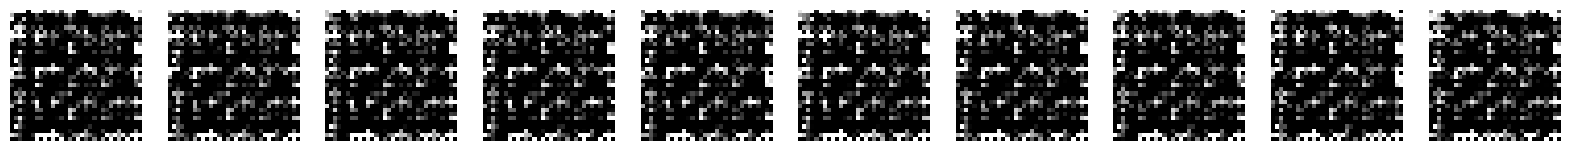


Saved to ./output/example_img_020.png


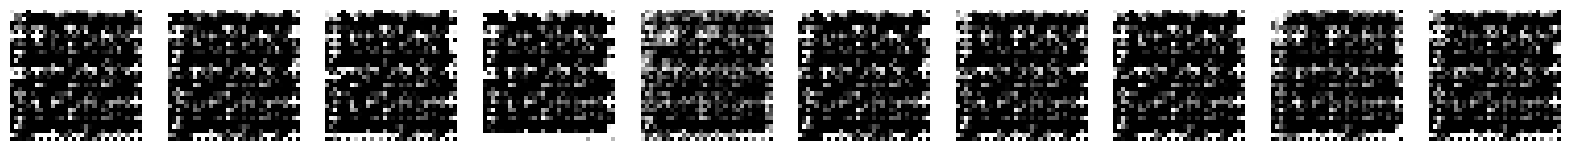

469/469 ━━━━━━━━━━━━━━━━━━━━ 296s 631ms/step - cdiv: -8.8139 - fake: -4.4094 - loss: -4.4073 - real: 4.4044 - reg: 4.4065 - val_cdiv: -17.2863 - val_fake: -12.7090 - val_real: 4.5773
Epoch 22/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 613ms/step - cdiv: -9.2908 - fake: -4.6381 - loss: -4.6546 - real: 4.6527 - reg: 4.6362
Saved to ./output/generated_img_021.png


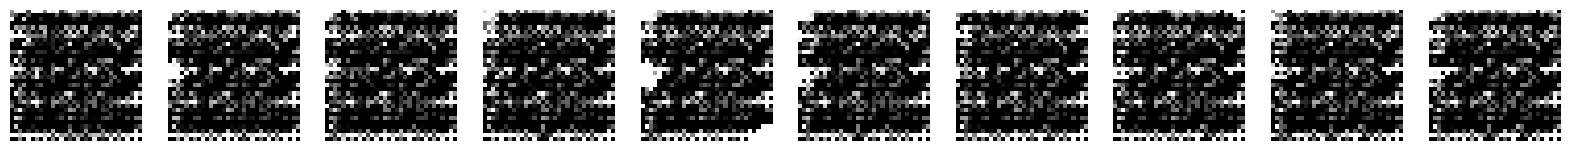


Saved to ./output/example_img_021.png


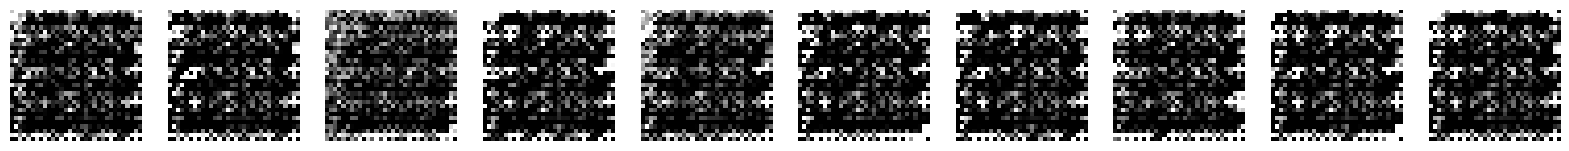

469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 628ms/step - cdiv: -9.4258 - fake: -4.7146 - loss: -4.7131 - real: 4.7112 - reg: 4.7127 - val_cdiv: -16.6234 - val_fake: -11.8614 - val_real: 4.7620
Epoch 23/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - cdiv: -9.7650 - fake: -4.8766 - loss: -4.8930 - real: 4.8884 - reg: 4.8721
Saved to ./output/generated_img_022.png


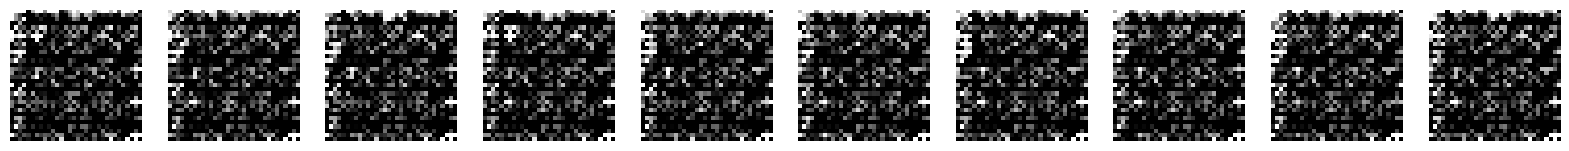


Saved to ./output/example_img_022.png


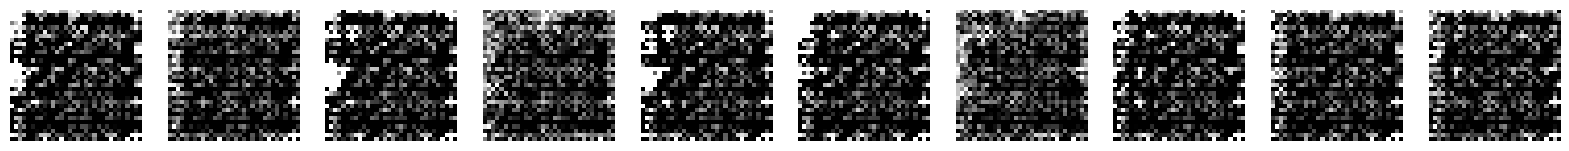

469/469 ━━━━━━━━━━━━━━━━━━━━ 295s 630ms/step - cdiv: -9.8373 - fake: -4.9196 - loss: -4.9189 - real: 4.9177 - reg: 4.9183 - val_cdiv: -16.3878 - val_fake: -11.4009 - val_real: 4.9869
Epoch 24/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - cdiv: -9.8988 - fake: -4.9390 - loss: -4.9570 - real: 4.9597 - reg: 4.9418
Saved to ./output/generated_img_023.png


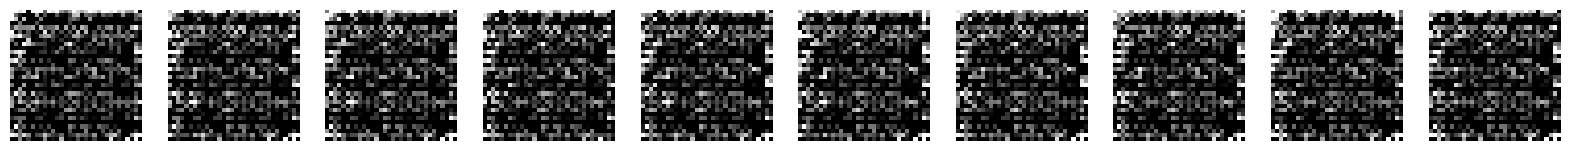


Saved to ./output/example_img_023.png


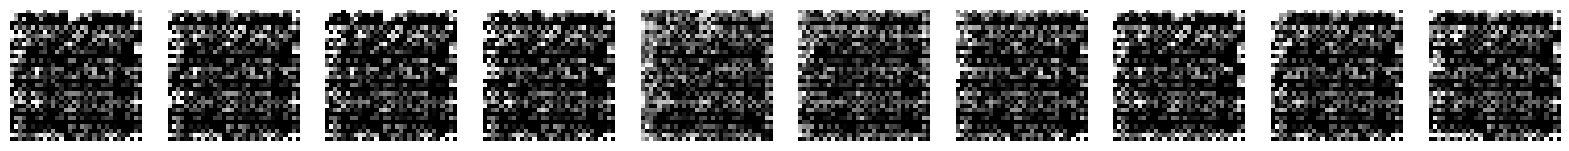

469/469 ━━━━━━━━━━━━━━━━━━━━ 296s 632ms/step - cdiv: -9.9298 - fake: -4.9649 - loss: -4.9641 - real: 4.9649 - reg: 4.9657 - val_cdiv: -15.5505 - val_fake: -10.6189 - val_real: 4.9316
Epoch 25/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - cdiv: -9.9438 - fake: -4.9618 - loss: -4.9794 - real: 4.9820 - reg: 4.9644
Saved to ./output/generated_img_024.png


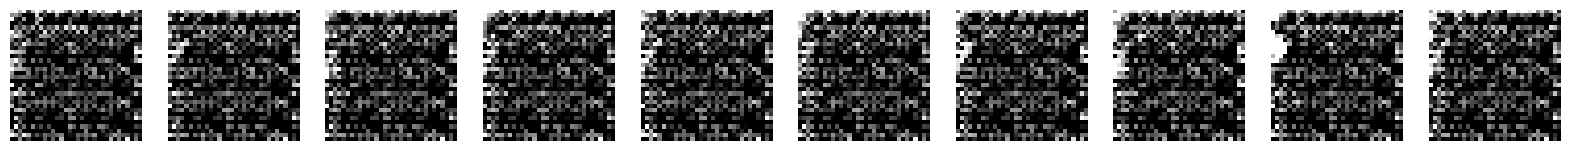


Saved to ./output/example_img_024.png


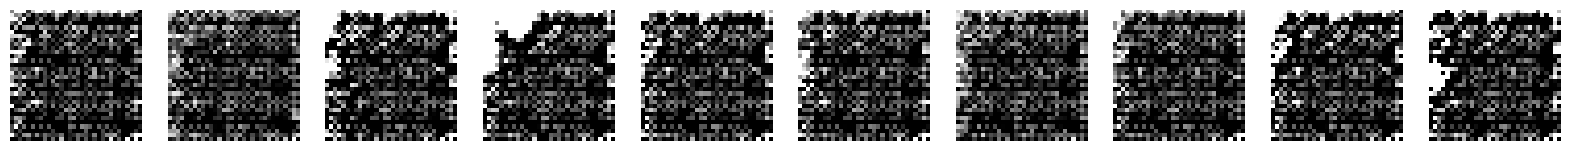

469/469 ━━━━━━━━━━━━━━━━━━━━ 299s 638ms/step - cdiv: -9.9646 - fake: -4.9822 - loss: -4.9816 - real: 4.9825 - reg: 4.9830 - val_cdiv: -14.9446 - val_fake: -9.9587 - val_real: 4.9859
Epoch 26/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 631ms/step - cdiv: -9.9629 - fake: -4.9711 - loss: -4.9885 - real: 4.9918 - reg: 4.9743
Saved to ./output/generated_img_025.png


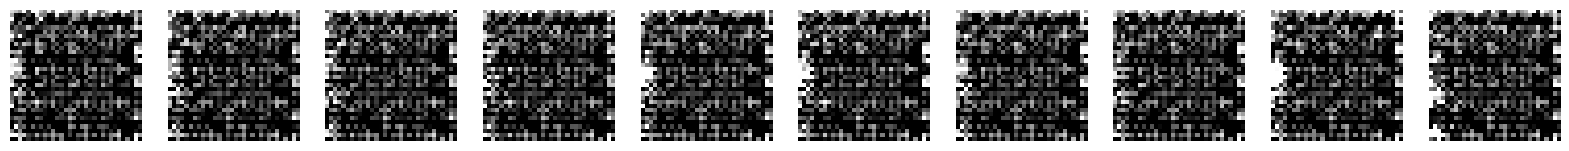


Saved to ./output/example_img_025.png


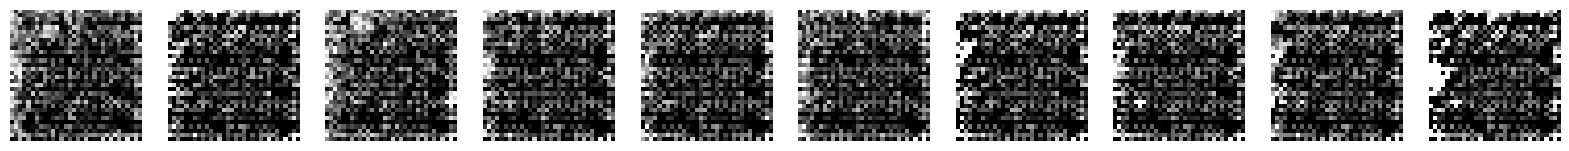

469/469 ━━━━━━━━━━━━━━━━━━━━ 303s 647ms/step - cdiv: -9.9731 - fake: -4.9863 - loss: -4.9856 - real: 4.9868 - reg: 4.9875 - val_cdiv: -14.2195 - val_fake: -9.2454 - val_real: 4.9741
Epoch 27/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 628ms/step - cdiv: -9.9616 - fake: -4.9708 - loss: -4.9887 - real: 4.9908 - reg: 4.9729
Saved to ./output/generated_img_026.png


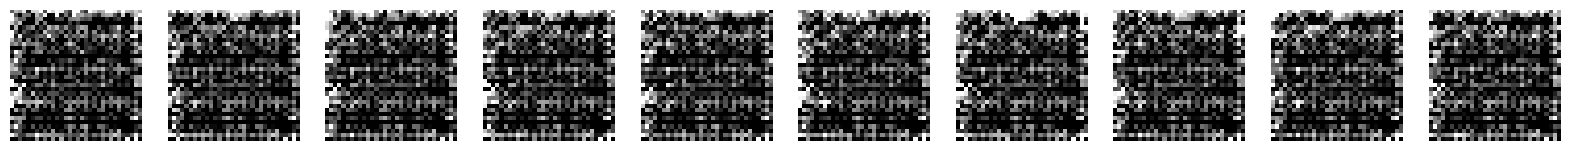


Saved to ./output/example_img_026.png


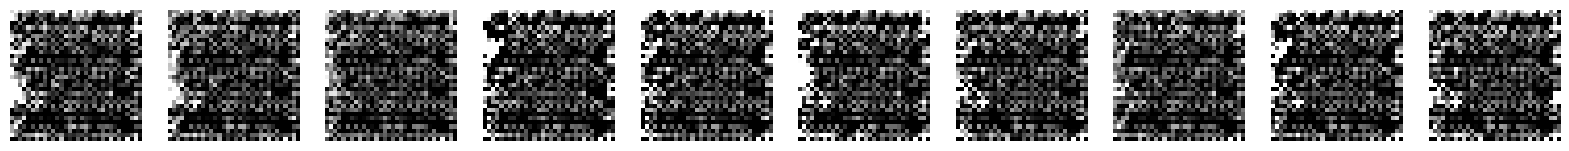

469/469 ━━━━━━━━━━━━━━━━━━━━ 321s 644ms/step - cdiv: -9.9690 - fake: -4.9844 - loss: -4.9838 - real: 4.9845 - reg: 4.9851 - val_cdiv: -13.5481 - val_fake: -8.5552 - val_real: 4.9929
Epoch 28/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - cdiv: -9.9436 - fake: -4.9615 - loss: -4.9795 - real: 4.9821 - reg: 4.9641
Saved to ./output/generated_img_027.png


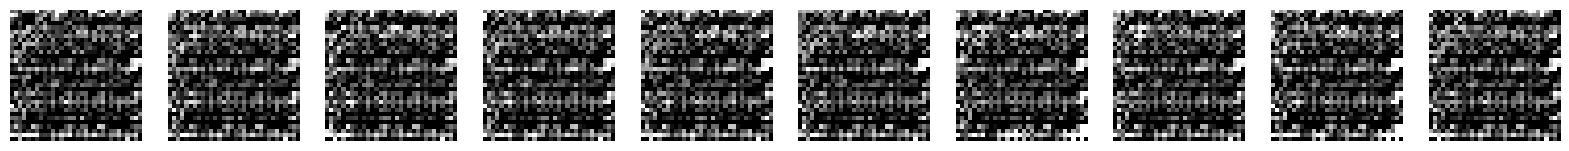


Saved to ./output/example_img_027.png


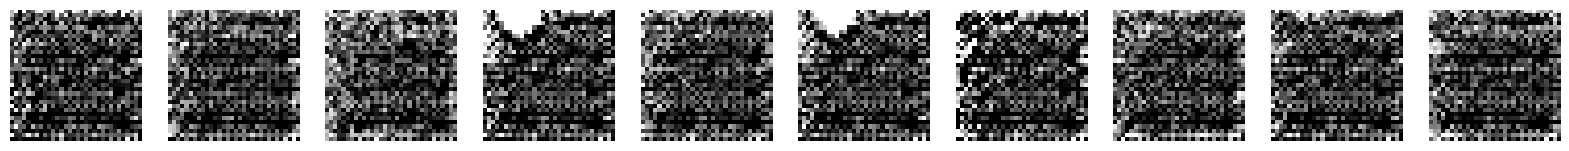

469/469 ━━━━━━━━━━━━━━━━━━━━ 309s 660ms/step - cdiv: -9.9370 - fake: -4.9681 - loss: -4.9678 - real: 4.9689 - reg: 4.9692 - val_cdiv: -12.9646 - val_fake: -7.9773 - val_real: 4.9873
Epoch 29/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - cdiv: -9.8990 - fake: -4.9408 - loss: -4.9589 - real: 4.9582 - reg: 4.9401
Saved to ./output/generated_img_028.png


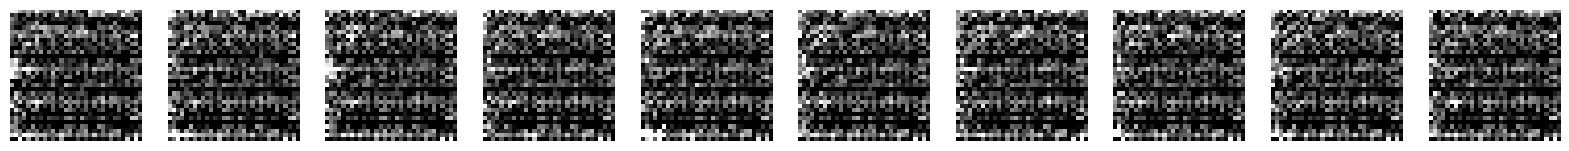


Saved to ./output/example_img_028.png


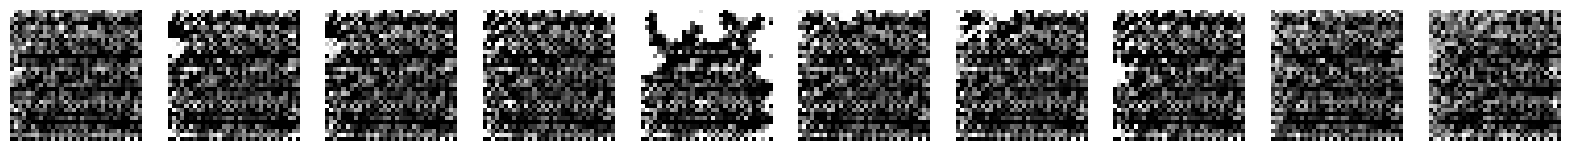

469/469 ━━━━━━━━━━━━━━━━━━━━ 306s 653ms/step - cdiv: -9.8976 - fake: -4.9493 - loss: -4.9491 - real: 4.9483 - reg: 4.9485 - val_cdiv: -12.6279 - val_fake: -7.7135 - val_real: 4.9145
Epoch 30/120
469/469 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - cdiv: -9.8372 - fake: -4.9074 - loss: -4.9253 - real: 4.9298 - reg: 4.9118
Saved to ./output/generated_img_029.png


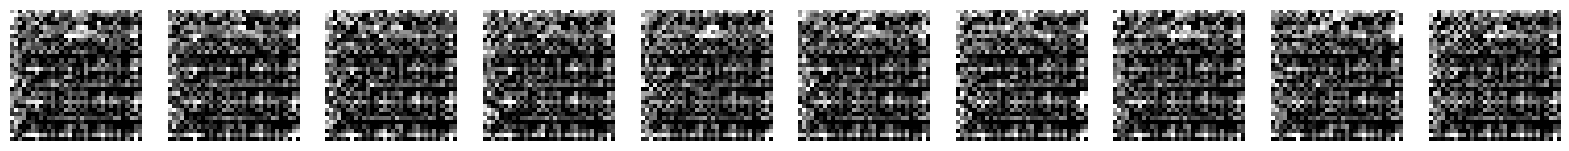


Saved to ./output/example_img_029.png


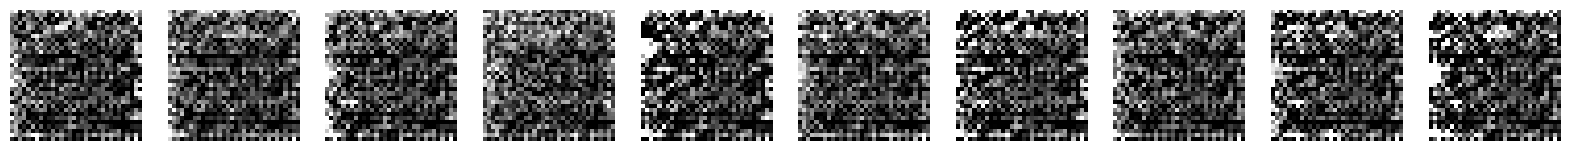

469/469 ━━━━━━━━━━━━━━━━━━━━ 314s 669ms/step - cdiv: -9.8245 - fake: -4.9120 - loss: -4.9115 - real: 4.9124 - reg: 4.9130 - val_cdiv: -12.0664 - val_fake: -7.2637 - val_real: 4.8027
Epoch 31/120
 64/469 ━━━━━━━━━━━━━━━━━━━━ 4:20 644ms/step - cdiv: -9.6997 - fake: -4.8061 - loss: -4.8922 - real: 4.8936 - reg: 4.8075

In [ ]:
class SaveModel(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        model.save_weights("./models/model.weights.h5")

save_model_callback = SaveModel()

history = ebm.fit(
    x_train,
    shuffle=True,
    epochs=EPOCHS,
    validation_data=x_test,
    callbacks=[
        save_model_callback,
        tensorboard_callback,
        image_generator_callback,
    ],
)

In [ ]:

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['cdiv'], label='Train CD Loss')
plt.plot(history.history['val_cdiv'], label='Val CD Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('EBM Training Loss Curve')
plt.savefig("loss_curve.png")
plt.show()


## 4. Generate images <a name="generate"></a>

In [ ]:
start_imgs = (
    np.random.uniform(size=(10, IMAGE_SIZE, IMAGE_SIZE, CHANNELS)) * 2 - 1
)

In [ ]:
display(start_imgs)

In [ ]:
gen_img = generate_samples(
    ebm.model,
    start_imgs,
    steps=1000,
    step_size=STEP_SIZE,
    noise=NOISE,
    return_img_per_step=True,
)

In [ ]:
display(gen_img[-1].numpy())

In [ ]:
imgs = []
for i in [0, 1, 3, 5, 10, 30, 50, 100, 300, 999]:
    imgs.append(gen_img[i].numpy()[6])

display(np.array(imgs))